# TP5 -  Compromis Biais/Variance et autre
### Sharaine MALARVIJY 21206543

## I. Chargement et visualisation des données

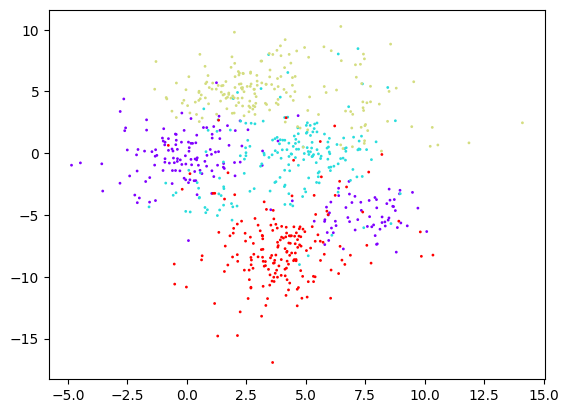

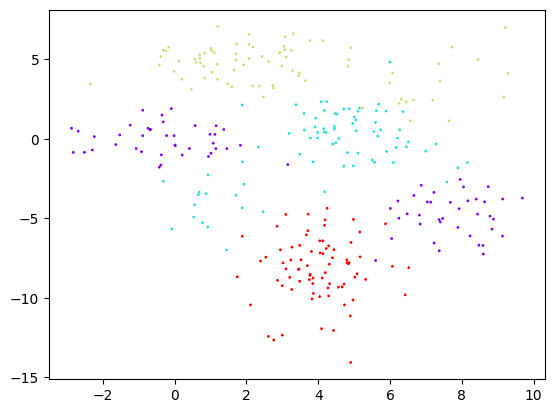

Dans la base de donnée TP5.npz
Il y a 748 points dans la base d’apprentissage
Il y a 312 points dans la base de test
La dimension des données sont de (748, 2) pour la base d’apprentissage
La dimension des données sont de (312, 2) pour la base de test
Il y a 4 classe
Effectif de 156 dans la classe 0
Effectif de 156 dans la classe 1
Effectif de 156 dans la classe 2
Effectif de 156 dans la classe 3


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import mode
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


data = np.load("TP5.npz")
X_train, y_train, X_test, y_test = (data[key] for key in ["X_train", "y_train", "X_test", "y_test"])
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=1, cmap='rainbow');
plt.show()
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=1, cmap='rainbow');
plt.show()

print("Dans la base de donnée TP5.npz")
print(f"Il y a {X_train.shape[0]} points dans la base d’apprentissage")
print(f"Il y a {X_test.shape[0]} points dans la base de test")

print(f"La dimension des données sont de {X_train.shape} pour la base d’apprentissage")
print(f"La dimension des données sont de {X_test.shape} pour la base de test")

nb_classe = round(max(y_test)+1)
print(f"Il y a {nb_classe} classe") 

for i in range(nb_classe):
    print(f"Effectif de {X_test[y_test==i].size} dans la classe {i}")

## II. Calcul du biais et de la variance du classifieur 1PPV

In [2]:
def KPPV(X_train, y_train, k, Nrun): 
    prediction_list = []
    for i in range(Nrun):
        X_train_run, _, y_train_run, _ = train_test_split(X_train, y_train, train_size=0.6, random_state=543+i)
        neigh = KNeighborsClassifier(n_neighbors=k)
        neigh.fit(X_train_run, y_train_run)
        prediction = neigh.predict(X_test)
        prediction_list.append(prediction)
    return prediction_list

#modes.mode return la classe la plus predite pour les 30 run 
#modes.count return le nbre de fois où la classe est prédite 

def calcul_bias_variance(prediction_list, y_test, Nrun) : 
    bias_list = []
    var_list = []
    modes = mode(np.array(prediction_list), axis=0)

    for i in range(len(y_test)):
        if modes.mode[i] == y_test[i]: 
            bias_list.append(0)
        else :
            bias_list.append(1)
    
    bias = np.mean(bias_list)

    for c in modes.count:
        var_list.append(1-c/Nrun)
    variance = np.mean(var_list)
    return bias, variance

Nrun = 30

prediction_list = KPPV(X_train, y_train, 1, Nrun)

bias, variance = calcul_bias_variance(prediction_list, y_test, Nrun) 

print("Pour 1PPV : ")
print(f"Biais = {bias}")
print(f"Variance = {variance}")

Pour 1PPV : 
Biais = 0.1346153846153846
Variance = 0.07905982905982907


## III. Etude du compromis biais/variance du classifieur k-PPV

Meilleur compromis biais variance à K = 15


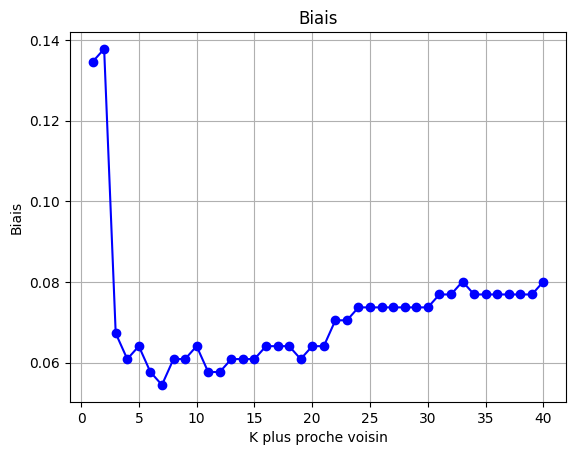

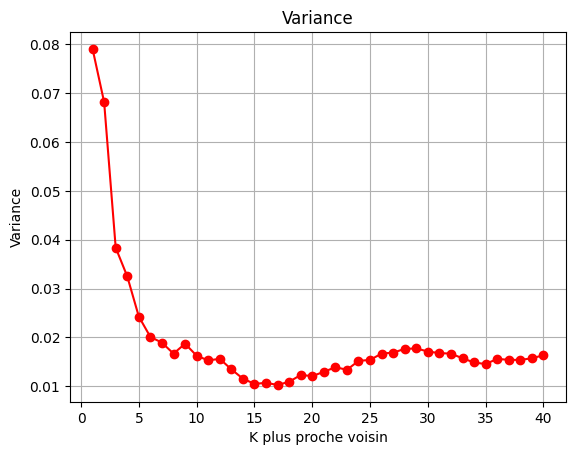

In [3]:
bias_list = []
variance_list = []

axis_x = list(range(1, 41))

for i in axis_x:
    prediction_list = KPPV(X_train, y_train, i, Nrun)
    bias, variance = calcul_bias_variance(prediction_list, y_test, Nrun) 
    bias_list.append(bias)
    variance_list.append(variance)

bias_variance_list = np.array(bias_list)+np.array(variance_list)
k_optimal = np.argmin(bias_variance_list)+1

print("Meilleur compromis biais variance à K =", k_optimal)


def affiche_bias_variance(axis_x, bias_list, variance_list, x_label):
    plt.figure()
    plt.plot(axis_x, bias_list, 'o-', color='blue')
    plt.title("Biais")
    plt.xlabel(x_label)
    plt.ylabel("Biais")
    plt.grid(True)


    plt.figure()
    plt.plot(axis_x, variance_list, 'o-', color='red')
    plt.title("Variance")
    plt.xlabel(x_label)
    plt.ylabel("Variance")
    plt.grid(True)

affiche_bias_variance(axis_x, bias_list, variance_list, "K plus proche voisin")


## IV. Reprendre la même étude en utilisant un arbre de décision

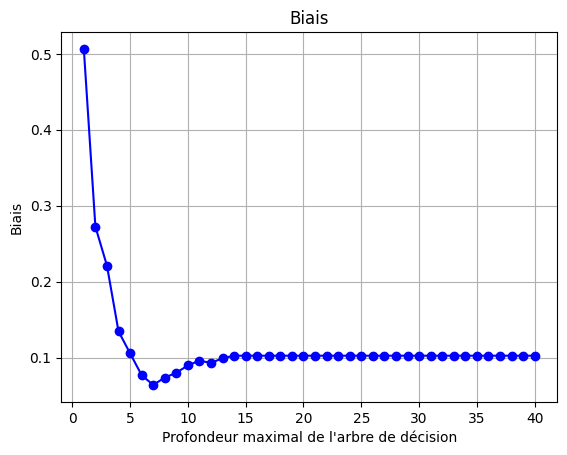

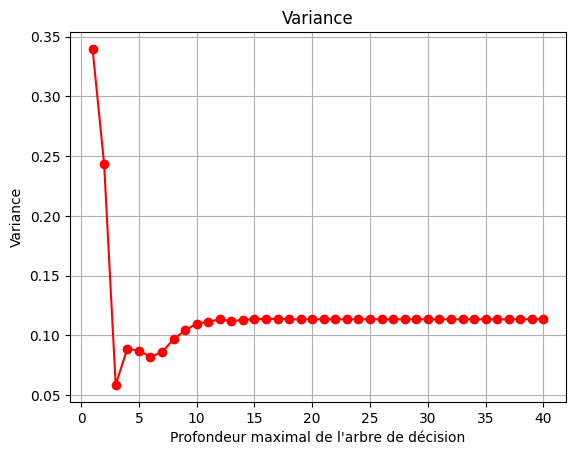

In [4]:
def DecisionTree(X_train, y_train, k, Nrun): 
    prediction_list = []
    for i in range(Nrun):
        X_train_run, _, y_train_run, _ = train_test_split(X_train, y_train, train_size=0.6, random_state=543+i)
        tree1 = tree.DecisionTreeClassifier(criterion='entropy', max_depth = k, random_state= 543) 
        tree1.fit(X_train_run, y_train_run)
        prediction = tree1.predict(X_test)
        prediction_list.append(prediction)   
    return prediction_list


bias_list = []
variance_list = []

for i in axis_x:
    prediction_list = DecisionTree(X_train, y_train, i, Nrun)
    bias, variance = calcul_bias_variance(prediction_list, y_test, Nrun) 
    bias_list.append(bias)
    variance_list.append(variance)

bias_variance_list = np.array(bias_list)+np.array(variance_list)
max_depth_optimal = np.argmin(bias_variance_list)+1

affiche_bias_variance(axis_x, bias_list, variance_list, "Profondeur maximal de l'arbre de décision")

## V. Reprendre la même étude avec les random forest

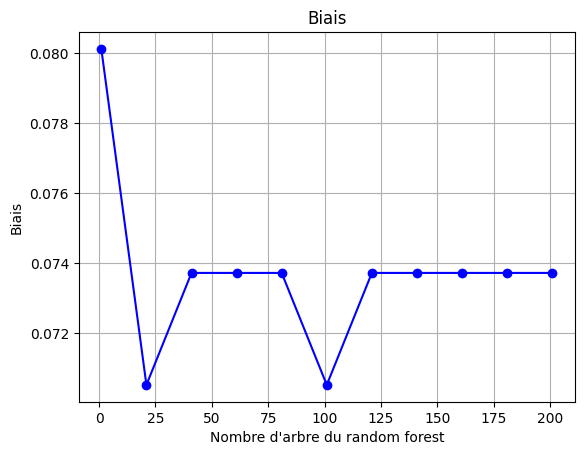

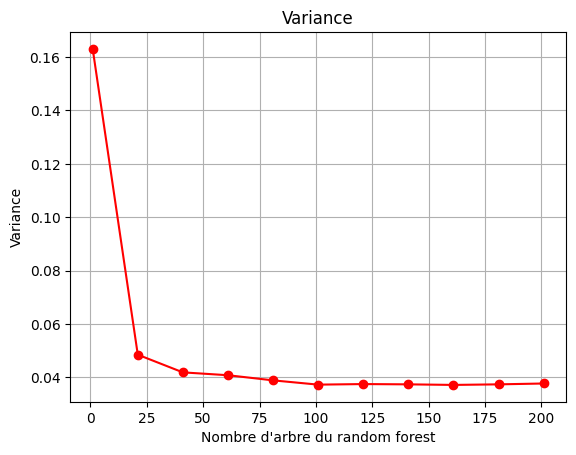

In [5]:
def RandomForest(X_train, y_train, k, Nrun):
    prediction_list = []
    for i in range(Nrun):
        X_train_run, _, y_train_run, _ = train_test_split(X_train, y_train, train_size=0.6, random_state=543+i)
        RF = RandomForestClassifier(criterion='entropy', n_estimators=k, random_state=543, n_jobs=-1) 
        RF.fit(X_train_run, y_train_run)
        prediction = RF.predict(X_test)
        prediction_list.append(prediction)   
    return prediction_list


bias_list = []
variance_list = []
nb_arbre = list(range(1, 202, 20))

for i in nb_arbre:
    prediction_list = RandomForest(X_train, y_train, i, Nrun)
    bias, variance = calcul_bias_variance(prediction_list, y_test, Nrun) 
    bias_list.append(bias)
    variance_list.append(variance)

bias_variance_list = np.array(bias_list)+np.array(variance_list)
nb_arbre_optimal = np.argmin(bias_variance_list)
nb_arbre_optimal = nb_arbre[nb_arbre_optimal]


affiche_bias_variance(nb_arbre, bias_list, variance_list, "Nombre d'arbre du random forest")

## VI. Test sur un nouveau jeu de données

In [6]:
RF = RandomForestClassifier(criterion='entropy', max_depth=max_depth_optimal, n_estimators=nb_arbre_optimal, random_state=543, n_jobs=-1) 
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

class_report = classification_report(y_test, y_pred)

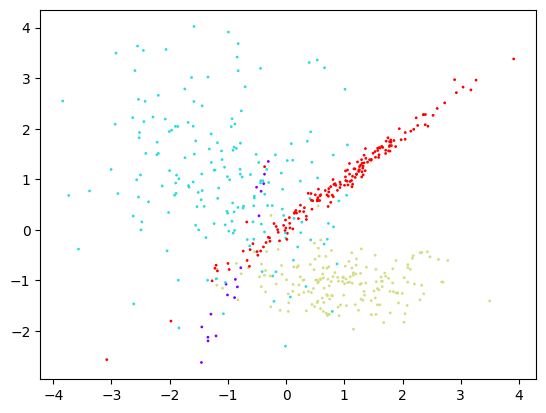

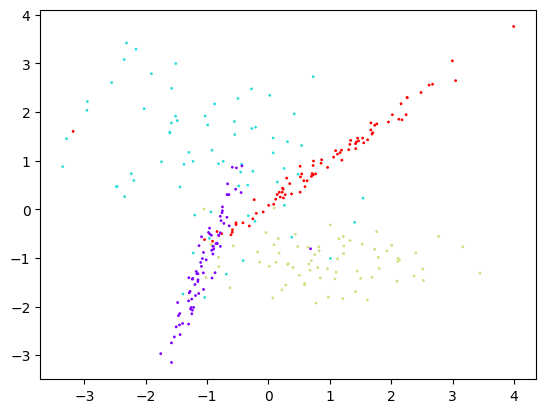

Dans la base de donnée TP5a.npz
Il y a 546 points dans la base d’apprentissage
Il y a 300 points dans la base de test
La dimension des données sont de (546, 2) pour la base d’apprentissage
La dimension des données sont de (300, 2) pour la base de test
Il y a 4 classe
Effectif de 152 dans la classe 0
Effectif de 138 dans la classe 1
Effectif de 144 dans la classe 2
Effectif de 166 dans la classe 3


In [7]:
data = np.load("TP5a.npz")
X_train, y_train, X_test, y_test = (data[key] for key in ["X_train", "y_train", "X_test", "y_test"])

plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=1, cmap='rainbow');
plt.show()
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=1, cmap='rainbow');
plt.show()

print("Dans la base de donnée TP5a.npz")
print(f"Il y a {X_train.shape[0]} points dans la base d’apprentissage")
print(f"Il y a {X_test.shape[0]} points dans la base de test")

print(f"La dimension des données sont de {X_train.shape} pour la base d’apprentissage")
print(f"La dimension des données sont de {X_test.shape} pour la base de test")

nb_classe = round(max(y_test)+1)
print(f"Il y a {nb_classe} classe") 

for i in range(nb_classe):
    print(f"Effectif de {X_test[y_test==i].size} dans la classe {i}")


On peut voir que la base de donnée n'est pas équilibré. 

In [8]:
RF = RandomForestClassifier(criterion='entropy', max_depth=max_depth_optimal, n_estimators=nb_arbre_optimal, random_state=543, n_jobs=-1) 
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

print("\nBase de donnée TP5.npz")
print(class_report)

print("Base de donnée TP5a.npz")
print(classification_report(y_test, y_pred)) 


Base de donnée TP5.npz
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94        78
         1.0       0.90      0.90      0.90        78
         2.0       0.99      0.91      0.95        78
         3.0       0.96      0.97      0.97        78

    accuracy                           0.94       312
   macro avg       0.94      0.94      0.94       312
weighted avg       0.94      0.94      0.94       312

Base de donnée TP5a.npz
              precision    recall  f1-score   support

           0       0.85      0.45      0.59        76
           1       0.71      0.77      0.74        69
           2       0.84      0.92      0.87        72
           3       0.75      0.96      0.85        83

    accuracy                           0.78       300
   macro avg       0.79      0.77      0.76       300
weighted avg       0.79      0.78      0.76       300



On voit que comparé à la première basse de donnée l'accuracy a grandement chuté. Le désquilibre des classes est flagrant quand on regarde le recall de la class 0

Ma première solution est d'attribuer un poids plus élever au classe les moins representer

In [9]:
RF = RandomForestClassifier(class_weight="balanced_subsample",criterion='entropy', max_depth=max_depth_optimal, n_estimators=nb_arbre_optimal, random_state=543, n_jobs=-1) 
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

print("Base de donnée TP5a.npz aprés équilibrage par poids dans le random forest")
print(classification_report(y_test, y_pred)) 

Base de donnée TP5a.npz aprés équilibrage par poids dans le random forest
              precision    recall  f1-score   support

           0       0.86      0.50      0.63        76
           1       0.74      0.77      0.75        69
           2       0.87      0.92      0.89        72
           3       0.76      0.99      0.86        83

    accuracy                           0.80       300
   macro avg       0.81      0.79      0.78       300
weighted avg       0.81      0.80      0.78       300



Ma deuxième solution est d'utiliser l'option stratified dans train_test_split

In [10]:
X_train2, _, y_train2, _ = train_test_split(X_train, y_train, train_size=0.95, random_state=543, stratify=y_train)

RF = RandomForestClassifier(class_weight="balanced_subsample",criterion='entropy', max_depth=max_depth_optimal, n_estimators=nb_arbre_optimal, random_state=543, n_jobs=-1) 
RF.fit(X_train2, y_train2)
y_pred = RF.predict(X_test)

print("Base de donnée TP5a.npz après stratification et random forest")
print(classification_report(y_test, y_pred)) 

Base de donnée TP5a.npz après stratification et random forest
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        76
           1       0.73      0.75      0.74        69
           2       0.87      0.92      0.89        72
           3       0.78      0.99      0.87        83

    accuracy                           0.81       300
   macro avg       0.81      0.80      0.80       300
weighted avg       0.81      0.81      0.80       300

